# Supervised Learning — Parts 5 to 7
## Spam / Phishing Email Detection — CEAS_08 Dataset

## 0. Setup

### 0.1 Imports and configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     train_test_split)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score)

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
MAX_TFIDF_FEATURES = 300
NGRAM_RANGE = (1, 2)
MIN_DF = 2

TRAIN_CSV = Path("spam_train_cleaned.csv")
TEST_CSV = Path("spam_test_cleaned.csv")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

### 0.2 Load the cleaned dataset

In [2]:
if not (TRAIN_CSV.exists() and TEST_CSV.exists()):
    raise FileNotFoundError(
        f"{TRAIN_CSV} / {TEST_CSV} not found. They come from LazyClassifier.ipynb."
    )

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
print("Train:", train_df.shape, " Test:", test_df.shape)
train_df.head(3)

Train: (31311, 16)  Test: (7828, 16)


,label,urls,hour,combined_text,capital_letter_count,capital_ratio,exclamation_count,question_count,special_char_count,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,0,1,2,volunteers are needed for alumni phonothon 200...,37,0.055306,0,0,2,0,0,0,0,0,0,1
1,0,0,0,re opensuse opensuse and faxes on sunday 10 fe...,85,0.048935,0,2,42,0,0,0,0,0,0,1
2,0,1,2,re r matching a period in grep on 08 05 2008 0...,69,0.045128,0,4,114,0,0,0,0,0,0,1


### 0.3 Sanity checks

In [3]:
print("Train duplicates:", train_df["combined_text"].duplicated().sum())
print("Test duplicates :", test_df["combined_text"].duplicated().sum())
print("Missing values  :", train_df.isna().sum().sum())
print("Class balance:")
print((train_df["label"].value_counts(normalize=True) * 100).round(2).to_string())

Train duplicates: 3900
Test duplicates : 793
Missing values  : 0
Class balance:
label
1    55.77
0    44.23


## Part 5 — Feature Preparation

### 5.1 Duplicate removal

In [4]:
train_df = train_df.drop_duplicates(subset="combined_text").reset_index(drop=True)
test_df = test_df.drop_duplicates(subset="combined_text").reset_index(drop=True)

print("Train after dedupe:", train_df.shape)
print("Test  after dedupe:", test_df.shape)

Train after dedupe: (27411, 16)
Test  after dedupe: (7035, 16)


### 5.2 Data leakage review

In [5]:
leaky = [c for c in train_df.columns if "spam_ratio" in c or "receiver" in c]
same = set(train_df["combined_text"]) & set(test_df["combined_text"])

print("Label-derived columns present:", leaky or "none")
print("Emails shared by train and test:", len(same))

test_df = test_df[~test_df["combined_text"].isin(same)].reset_index(drop=True)
print("Test after removing the overlap:", test_df.shape)

Label-derived columns present: none
Emails shared by train and test: 388


### 5.3 Feature groups

In [6]:
TARGET = "label"
TEXT_COL = "combined_text"
NUMERIC_COLS = [c for c in train_df.columns if c not in (TARGET, TEXT_COL)]

FEATURE_COLS = [TEXT_COL] + NUMERIC_COLS

print("Text   :", TEXT_COL)
print(f"Numeric ({len(NUMERIC_COLS)}):", NUMERIC_COLS)

Text   : combined_text
Numeric (14): ['urls', 'hour', 'capital_letter_count', 'capital_ratio', 'exclamation_count', 'question_count', 'special_char_count', 'day_of_week_Friday', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday']


### 5.4 Preprocessing pipeline

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=MAX_TFIDF_FEATURES,
                                 ngram_range=NGRAM_RANGE, min_df=MIN_DF,
                                 sublinear_tf=True), TEXT_COL),
        ("numeric", MinMaxScaler(), NUMERIC_COLS),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

### 5.5 Resulting feature space

In [8]:
_probe = preprocessor.fit_transform(train_df[FEATURE_COLS])

print("Feature matrix:", _probe.shape)
print("Min value:", _probe.min(), "(non-negative keeps MultinomialNB valid)")
print("Missing values in features:", train_df[FEATURE_COLS].isna().sum().sum())

del _probe

Feature matrix: (27411, 314)
Min value: 0.0 (non-negative keeps MultinomialNB valid)
Missing values in features: 0


## Part 6 — Data Splitting

### 6.1 Train / test split

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df[FEATURE_COLS], train_df[TARGET],
    test_size=TEST_SIZE, stratify=train_df[TARGET], random_state=RANDOM_STATE
)
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET]

print(f"Train      : {X_train.shape[0]:,} rows")
print(f"Validation : {X_val.shape[0]:,} rows")
print(f"Test (held out): {X_test.shape[0]:,} rows")

Train      : 21,928 rows
Validation : 5,483 rows
Test (held out): 7,035 rows


### 6.2 Stratification check

In [10]:
pd.DataFrame({
    "train": y_train.value_counts(normalize=True) * 100,
    "validation": y_val.value_counts(normalize=True) * 100,
    "test": y_test.value_counts(normalize=True) * 100,
}).round(2)

,train,validation,test
label,,,
0,50.31,50.3,49.11
1,49.69,49.7,50.89


### 6.3 Cross-validation strategy

In [11]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
SCORING = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc"]

cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

### 6.4 Leakage prevention

In [12]:
def make_pipeline(estimator):
    """Fresh preprocessor per model so TF-IDF is fit on training folds only."""
    return Pipeline([
        ("prep", ColumnTransformer([
            ("text", TfidfVectorizer(max_features=MAX_TFIDF_FEATURES,
                                     ngram_range=NGRAM_RANGE, min_df=MIN_DF,
                                     sublinear_tf=True), TEXT_COL),
            ("numeric", MinMaxScaler(), NUMERIC_COLS),
        ])),
        ("model", estimator),
    ])


make_pipeline(MultinomialNB())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

### 6.5 Shared evaluation helper

In [13]:
results = []


def evaluate(name, estimator, cross_validate_too=True):
    pipe = make_pipeline(estimator)
    pipe.fit(X_train, y_train)

    pred_train = pipe.predict(X_train)
    pred_val = pipe.predict(X_val)
    proba_val = (pipe.predict_proba(X_val)[:, 1]
                 if hasattr(pipe["model"], "predict_proba") else None)

    row = {
        "model": name,
        "train_acc": accuracy_score(y_train, pred_train),
        "val_acc": accuracy_score(y_val, pred_val),
        "precision": precision_score(y_val, pred_val, average="macro", zero_division=0),
        "recall": recall_score(y_val, pred_val, average="macro"),
        "f1": f1_score(y_val, pred_val, average="macro"),
        "roc_auc": roc_auc_score(y_val, proba_val) if proba_val is not None else np.nan,
    }

    if cross_validate_too:
        cv_res = cross_validate(pipe, X_train, y_train, cv=cv,
                                scoring="f1_macro", n_jobs=-1)
        row["cv_f1_mean"] = cv_res["test_score"].mean()
        row["cv_f1_std"] = cv_res["test_score"].std()

    results.append(row)
    return pipe, row

## Part 7 — Baseline Model

### 7.1 Trivial reference — majority class

In [14]:
dummy_pipe, dummy_row = evaluate(
    "Dummy (majority class)",
    DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
)

pd.Series(dummy_row).to_frame("value").round(4)

,value
model,Dummy (majority class)
train_acc,0.503101
val_acc,0.503009
precision,0.251505
recall,0.5
f1,0.334668
roc_auc,0.5
cv_f1_mean,0.334709
cv_f1_std,0.000038


### 7.2 Baseline — Multinomial Naive Bayes

In [15]:
nb_pipe, nb_row = evaluate("MultinomialNB (baseline)", MultinomialNB())

pd.Series(nb_row).to_frame("value").round(4)

,value
model,MultinomialNB (baseline)
train_acc,0.950657
val_acc,0.947656
precision,0.948861
recall,0.947506
f1,0.947607
roc_auc,0.98849
cv_f1_mean,0.94942
cv_f1_std,0.003108


### 7.3 Classification report and confusion matrix

                   precision    recall  f1-score   support

   Legitimate (0)       0.93      0.97      0.95      2758
Spam/Phishing (1)       0.97      0.92      0.95      2725

         accuracy                           0.95      5483
        macro avg       0.95      0.95      0.95      5483
     weighted avg       0.95      0.95      0.95      5483



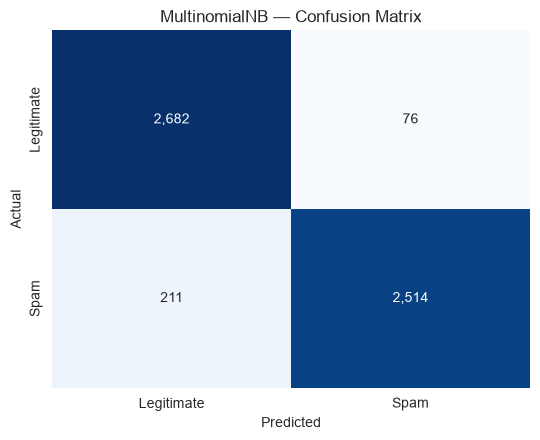

In [16]:
nb_pred = nb_pipe.predict(X_val)

print(classification_report(y_val, nb_pred,
                            target_names=["Legitimate (0)", "Spam/Phishing (1)"]))

cm = confusion_matrix(y_val, nb_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Legitimate", "Spam"], yticklabels=["Legitimate", "Spam"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("MultinomialNB — Confusion Matrix")
plt.tight_layout()
plt.show()

### 7.4 Underfitting check — train vs test vs cross-validation

In [17]:
baseline = pd.DataFrame(results).set_index("model")
baseline["train_val_gap"] = baseline["train_acc"] - baseline["val_acc"]

baseline.round(4)

,train_acc,val_acc,precision,recall,f1,roc_auc,cv_f1_mean,cv_f1_std,train_val_gap
model,,,,,,,,,
Dummy (majority class),0.5031,0.5030,0.2515,0.5000,0.3347,0.5000,0.3347,0.0000,0.0001
MultinomialNB (baseline),0.9507,0.9477,0.9489,0.9475,0.9476,0.9885,0.9494,0.0031,0.0030


### 7.5 Score to beat

In [18]:
BASELINE_F1 = nb_row["f1"]
BASELINE_ACC = nb_row["val_acc"]

print(f"Baseline macro F1 : {BASELINE_F1:.4f}")
print(f"Baseline accuracy : {BASELINE_ACC:.4f}")
print(f"Majority-class floor: {dummy_row['val_acc']:.4f}")

Baseline macro F1 : 0.9476
Baseline accuracy : 0.9477
Majority-class floor: 0.5030
